# Joint-lambda arPLS background subtraction

This notebook is an interactive plotting front end for `joint_arpls_background.py`. It uses the module's tested numerical functions instead of duplicating the arPLS implementation.

The automatically selected common $\lambda$ is the maximum-curvature point of a normalized joint L-curve. This is a reproducible, training-free model-selection heuristic; it does **not** establish a unique physical background.

Suggested workflow:

1. Configure either the separate NPY datasets or one NPZ input.
2. Run through the joint L-curve and neighboring-$\lambda$ diagnostics.
3. Inspect every fitted background and the corrected-spectrum overview.
4. Enable saving only after the result is satisfactory.

In [2]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np


def find_background_directory(start: Path) -> Path:
    """Find the folder containing joint_arpls_background.py."""
    start = start.resolve()
    candidates = [start, start / "Background_subtraction"]
    candidates.extend(parent / "Background_subtraction" for parent in start.parents)
    for candidate in candidates:
        if (candidate / "joint_arpls_background.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find Background_subtraction/joint_arpls_background.py. "
        "Start Jupyter from the project or Background_subtraction folder."
    )


BACKGROUND_DIRECTORY = find_background_directory(Path.cwd())
if str(BACKGROUND_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(BACKGROUND_DIRECTORY))

import joint_arpls_background as joint

plt.rcParams.update({"figure.dpi": 115, "axes.grid": True})
print(f"Using functions from: {Path(joint.__file__).resolve()}")

Using functions from: /home/zuxian/Documents/MyProjects/EELS_script/Background_subtraction/joint_arpls_background.py


## Parameters

Choose exactly one input mode. The existing stacked TACAW file is selected by default. Relative filenames are resolved from the `Background_subtraction` directory. Smaller $\lambda$ gives a more flexible baseline; larger $\lambda$ gives a smoother baseline.

In [3]:
# Input mode 1: separate one-dimensional NPY files.
DATASETS = [
    # {
    #     "label": "Spectrum 1",
    #     "energy_file": "energy_1.npy",
    #     "intensity_file": "intensity_1.npy",
    # },
    # {
    #     "label": "Spectrum 2",
    #     "energy_file": "energy_2.npy",
    #     "intensity_file": "intensity_2.npy",
    # },
]

# Input mode 2: NPZ containing keys 'energy' and 'intensity'.
NPZ_INPUT_FILE = None  # for example: "spectra.npz"

# Input mode 3: stacked (n_spectra, n_energy, 2) TACAW NPY file.
# Set this to None when using either input mode above.
STACKED_NPY_INPUT_FILE = "SiC_eels_thicknessdata_center_40px_new.npy"

# Energy interval and grid comparison
ENERGY_MIN = 180.0
ENERGY_MAX = 270.0  # meV
ENERGY_GRID_RTOL = 1e-7
ENERGY_GRID_ATOL = 1e-9

# Joint selection and arPLS controls
LAMBDA_GRID = np.logspace(2, 10, 33)
MANUAL_LAMBDA = None  # positive value bypasses automatic selection
ARPLS_RATIO = 1e-6
ARPLS_MAX_ITER = 100
DIAGNOSTIC_SPECTRUM_INDEX = 0

# Optional display-label override, especially useful with NPZ input.
LABELS_OVERRIDE = None  # for example: ["10 nm", "20 nm"]

# Saving is disabled while inspecting/tuning.
SAVE_RESULTS = False
SAVE_PLOTS = False
OUTPUT_FILE = BACKGROUND_DIRECTORY / "joint_arpls_results.npz"
CSV_OUTPUT_FILE = BACKGROUND_DIRECTORY / "joint_arpls_lambda_diagnostics.csv"
SPECTRUM_TEXT_DIRECTORY = BACKGROUND_DIRECTORY / "joint_arpls_spectra"
PLOT_DIRECTORY = BACKGROUND_DIRECTORY / "joint_arpls_plots"
PLOT_DPI = 250

## Load and validate the spectra

Energy axes are sorted with their corresponding intensities and must then match within the configured tolerance. Differing grids raise an error; the notebook never interpolates silently.

In [4]:
energy, intensities, labels = joint.load_datasets(
    datasets=DATASETS,
    npz_file=NPZ_INPUT_FILE,
    stacked_npy_file=STACKED_NPY_INPUT_FILE,
    base_directory=BACKGROUND_DIRECTORY,
    grid_rtol=ENERGY_GRID_RTOL,
    grid_atol=ENERGY_GRID_ATOL,
)

if LABELS_OVERRIDE is not None:
    if len(LABELS_OVERRIDE) != intensities.shape[0]:
        raise ValueError(
            f"LABELS_OVERRIDE has {len(LABELS_OVERRIDE)} entries, but "
            f"there are {intensities.shape[0]} spectra."
        )
    labels = list(LABELS_OVERRIDE)

if not 0 <= DIAGNOSTIC_SPECTRUM_INDEX < intensities.shape[0]:
    raise IndexError(
        f"DIAGNOSTIC_SPECTRUM_INDEX must be between 0 and "
        f"{intensities.shape[0] - 1}."
    )

original_snapshot = intensities.copy()
energy_mask, energy_selected, intensities_selected = joint.select_energy_range(
    energy, intensities, ENERGY_MIN, ENERGY_MAX
)

print(f"Spectra: {intensities.shape[0]}")
print(f"Full array shape: {intensities.shape}")
print(
    f"Selected interval: {energy_selected[0]:.4g} to "
    f"{energy_selected[-1]:.4g} meV ({energy_selected.size} points)"
)
print(f"Labels: {labels}")

Spectra: 4
Full array shape: (4, 600)
Selected interval: 180.1 to 269.3 meV (98 points)
Labels: ['Spectrum 1', 'Spectrum 2', 'Spectrum 3', 'Spectrum 4']


## Select one common $\lambda$

All spectra contribute through normalized residual and roughness measures combined by geometric means. Large-amplitude spectra therefore do not dominate merely because of their absolute scale.

In [5]:
if MANUAL_LAMBDA is None:
    selected_lambda, diagnostics = joint.select_joint_lambda(
        intensities_selected,
        LAMBDA_GRID,
        ratio=ARPLS_RATIO,
        max_iter=ARPLS_MAX_ITER,
    )
else:
    if not np.isfinite(MANUAL_LAMBDA) or MANUAL_LAMBDA <= 0:
        raise ValueError("MANUAL_LAMBDA must be None or finite and positive.")
    selected_lambda = float(MANUAL_LAMBDA)
    diagnostics = joint._manual_diagnostics(LAMBDA_GRID, selected_lambda)

selection_info = diagnostics["selection_info"]
print(f"Selected common lambda: {selected_lambda:.8g}")
print(f"Selection reliable: {selection_info['selection_reliable']}")
for message in selection_info["warnings"]:
    warnings.warn(message, RuntimeWarning)

Selected common lambda: 562.34133
Selection reliable: True


## Joint L-curve and curvature

The star and vertical dashed line mark the selected candidate. This figure is unavailable when `MANUAL_LAMBDA` bypasses the candidate evaluation.

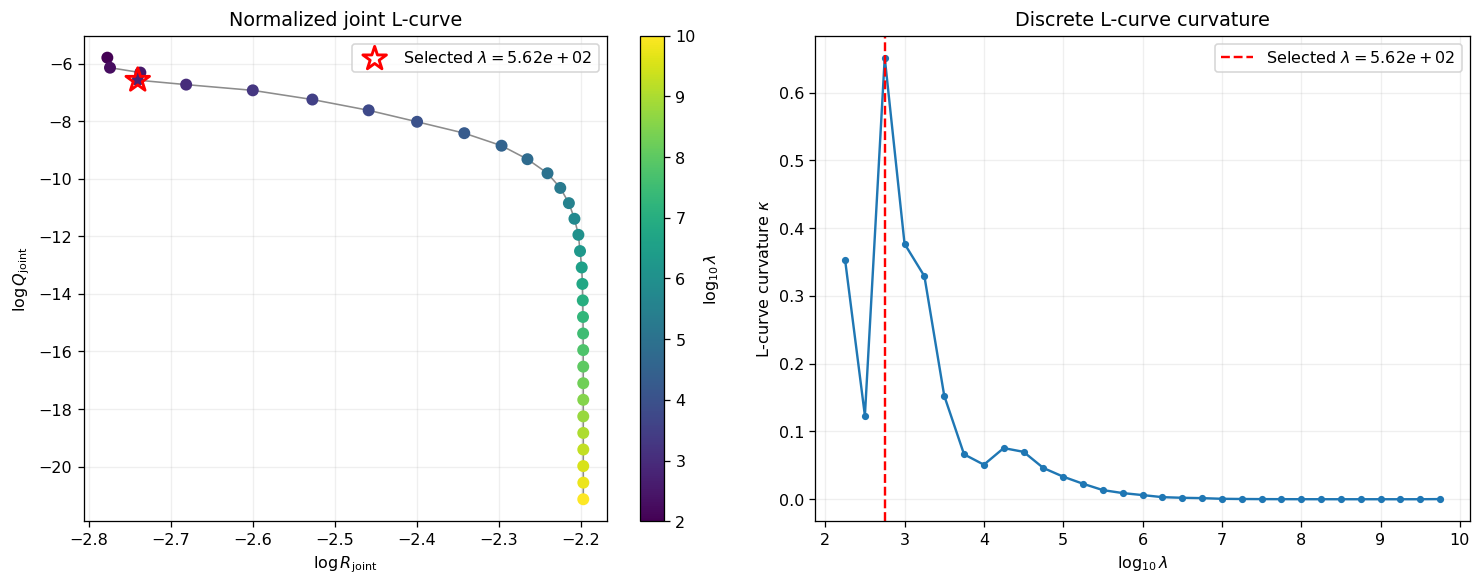

In [6]:
if MANUAL_LAMBDA is None:
    joint_figure, _ = joint.plot_joint_diagnostics(diagnostics)
    plt.show()
else:
    joint_figure = None
    print("Joint L-curve not calculated because MANUAL_LAMBDA is active.")

## Apply the selected common $\lambda$

In [7]:
baseline_selected, corrected_selected, weights_selected, fit_infos = (
    joint.apply_common_lambda(
        intensities_selected,
        selected_lambda=selected_lambda,
        ratio=ARPLS_RATIO,
        max_iter=ARPLS_MAX_ITER,
    )
)

assert np.array_equal(intensities, original_snapshot)
for label, info in zip(labels, fit_infos):
    print(
        f"{label}: converged={info['converged']}, "
        f"iterations={info['iterations']}, "
        f"relative change={float(info['relative_weight_change']):.3e}, "
        f"status={info['status']}"
    )
    if not info["converged"]:
        warnings.warn(f"Final fit did not converge for {label}: {info['status']}")

print(f"Negative corrected values retained: {np.any(corrected_selected < 0)}")

Spectrum 1: converged=True, iterations=29, relative change=6.937e-07, status=converged
Spectrum 2: converged=True, iterations=27, relative change=8.334e-07, status=converged
Spectrum 3: converged=True, iterations=30, relative change=9.195e-07, status=converged
Spectrum 4: converged=True, iterations=27, relative change=5.391e-07, status=converged
Negative corrected values retained: True


## Per-spectrum subtraction plots

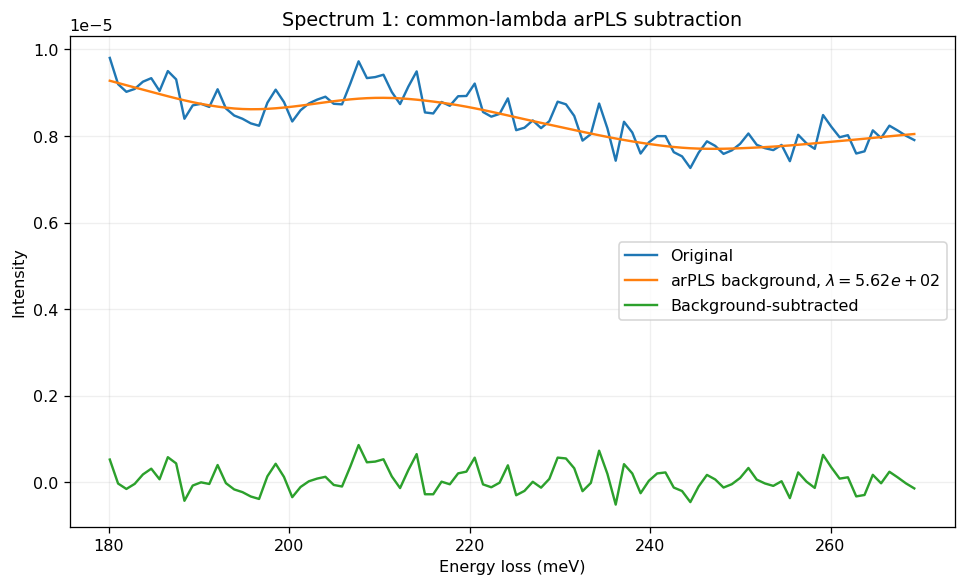

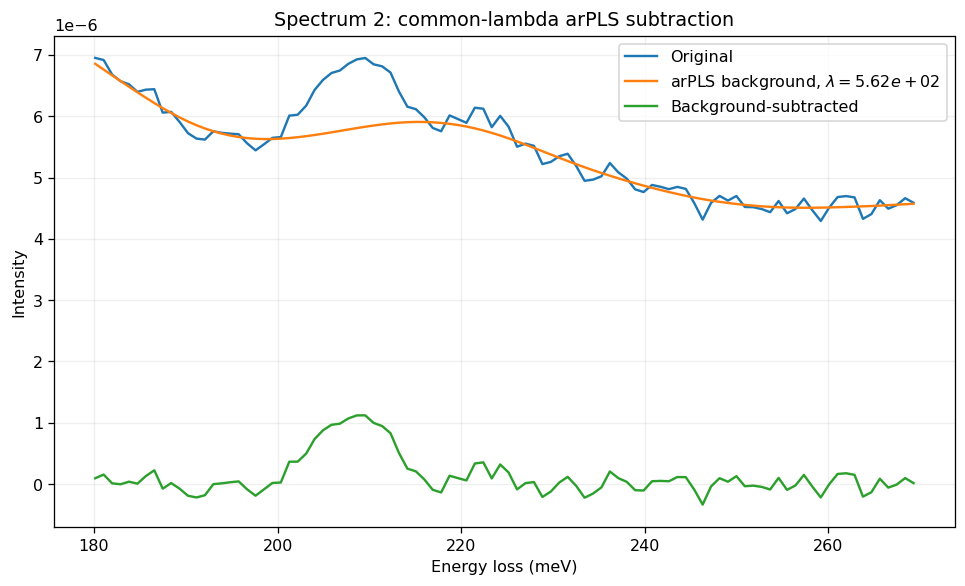

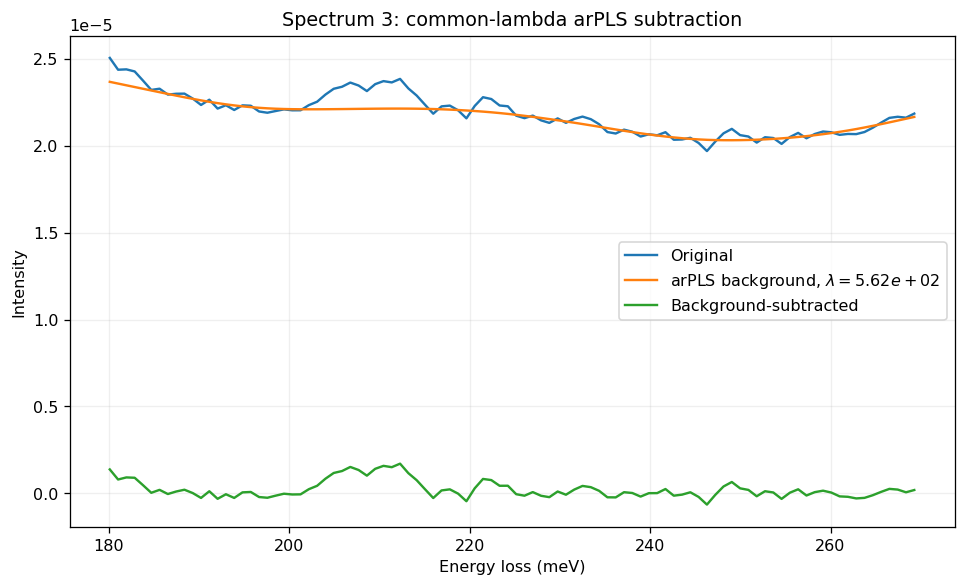

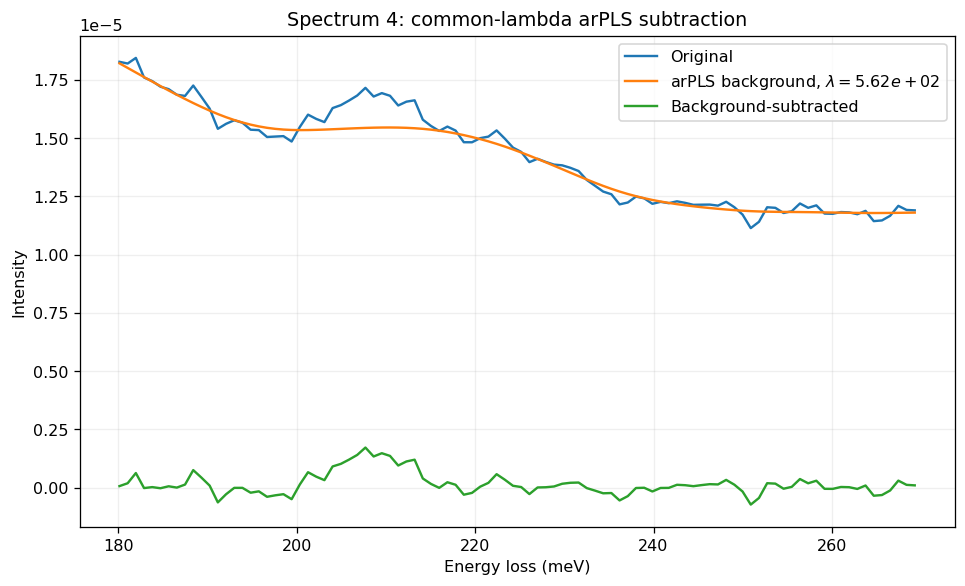

In [8]:
spectrum_figures = joint.plot_spectrum_results(
    energy_selected,
    intensities_selected,
    baseline_selected,
    corrected_selected,
    selected_lambda,
    labels,
)
plt.show()

## All-spectrum overview

The upper panel compares original spectra with dashed fitted backgrounds. The lower panel shows the quantitative, unclipped corrected spectra.

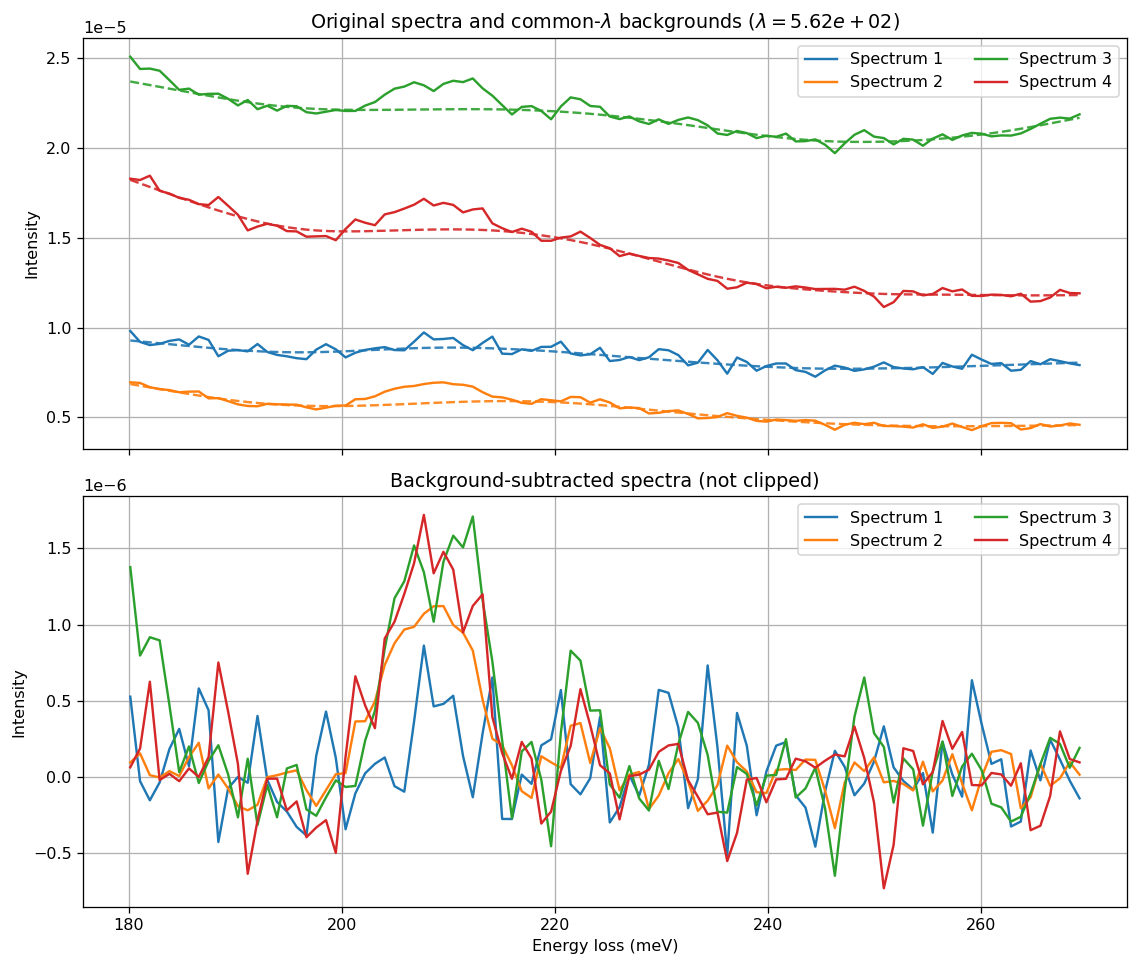

In [9]:
overview_figure, (original_axes, corrected_axes) = plt.subplots(
    2, 1, figsize=(10, 8.5), sharex=True
)
for index, label in enumerate(labels):
    line = original_axes.plot(
        energy_selected, intensities_selected[index], label=label
    )[0]
    original_axes.plot(
        energy_selected,
        baseline_selected[index],
        color=line.get_color(),
        linestyle="--",
        alpha=0.9,
    )
    corrected_axes.plot(
        energy_selected, corrected_selected[index], label=label
    )

original_axes.set_title(
    fr"Original spectra and common-$\lambda$ backgrounds ($\lambda={selected_lambda:.2e}$)"
)
original_axes.set_ylabel("Intensity")
original_axes.legend(ncol=2)
corrected_axes.set_title("Background-subtracted spectra (not clipped)")
corrected_axes.set_xlabel("Energy loss (meV)")
corrected_axes.set_ylabel("Intensity")
corrected_axes.legend(ncol=2)
overview_figure.tight_layout()
plt.show()

## Neighboring-$\lambda$ stability

This overlays the selected background with the immediately smaller and larger grid candidates for the configured diagnostic spectrum.

lambda=3.162e+02: converged=False, status=maximum_iterations_reached
lambda=5.623e+02: converged=True, status=converged
lambda=1.000e+03: converged=True, status=converged


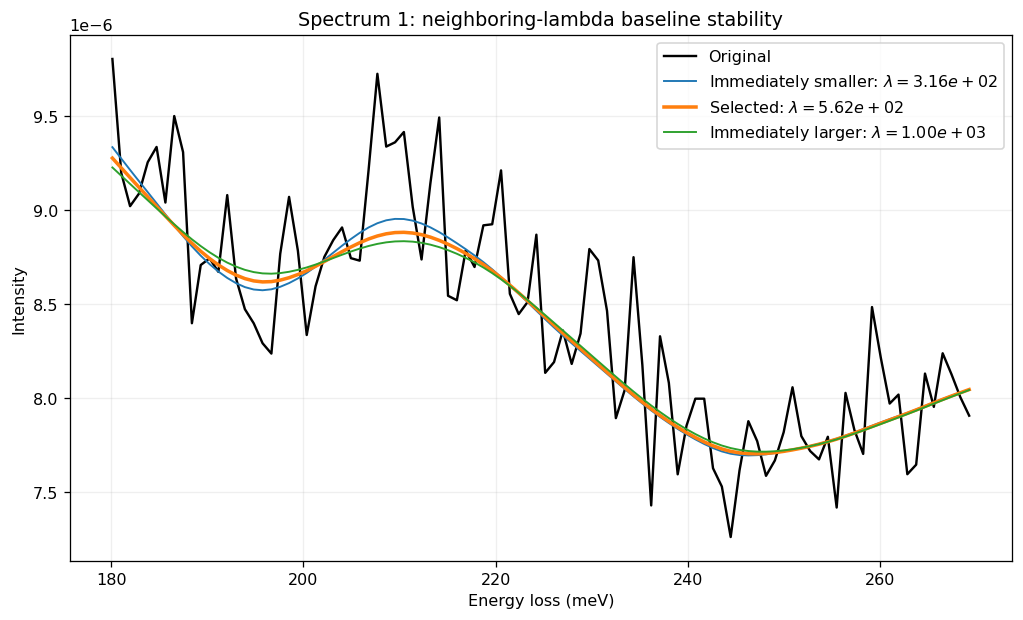

In [10]:
candidate_figure, candidate_infos = joint.plot_candidate_baselines(
    energy_selected,
    intensities_selected[DIAGNOSTIC_SPECTRUM_INDEX],
    np.asarray(LAMBDA_GRID),
    selected_lambda,
    ratio=ARPLS_RATIO,
    max_iter=ARPLS_MAX_ITER,
    label=labels[DIAGNOSTIC_SPECTRUM_INDEX],
)
for info in candidate_infos:
    print(
        f"lambda={float(info['lambda']):.3e}: "
        f"converged={info['converged']}, status={info['status']}"
    )
plt.show()

## Optional saving

Set `SAVE_RESULTS` and/or `SAVE_PLOTS` to `True` in the parameter cell and rerun. Background, corrected intensity, and final weights remain `NaN` outside the fitted interval in quantitative outputs.

In [ ]:
if SAVE_RESULTS:
    joint.save_results(
        output_file=OUTPUT_FILE,
        csv_output_file=CSV_OUTPUT_FILE,
        spectrum_text_directory=SPECTRUM_TEXT_DIRECTORY,
        energy=energy,
        intensities=intensities,
        energy_mask=energy_mask,
        baseline_selected=baseline_selected,
        corrected_selected=corrected_selected,
        weights_selected=weights_selected,
        selected_lambda=selected_lambda,
        diagnostics=diagnostics,
        labels=labels,
        energy_min=ENERGY_MIN,
        energy_max=ENERGY_MAX,
        ratio=ARPLS_RATIO,
        max_iter=ARPLS_MAX_ITER,
    )
    print(f"Saved quantitative results to {OUTPUT_FILE}")
else:
    print("Results not saved (SAVE_RESULTS=False).")

if SAVE_PLOTS:
    PLOT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    if joint_figure is not None:
        joint_figure.savefig(
            PLOT_DIRECTORY / "joint_lambda_selection.png",
            dpi=PLOT_DPI, bbox_inches="tight",
        )
    for index, figure in enumerate(spectrum_figures):
        figure.savefig(
            PLOT_DIRECTORY / f"spectrum_{index:03d}_background_subtraction.png",
            dpi=PLOT_DPI, bbox_inches="tight",
        )
    overview_figure.savefig(
        PLOT_DIRECTORY / "all_spectra_overview.png",
        dpi=PLOT_DPI, bbox_inches="tight",
    )
    candidate_figure.savefig(
        PLOT_DIRECTORY / "neighboring_lambda_baselines.png",
        dpi=PLOT_DPI, bbox_inches="tight",
    )
    print(f"Saved plots to {PLOT_DIRECTORY}")
else:
    print("Plots not saved (SAVE_PLOTS=False).")

## Optional built-in verification

This runs the deterministic synthetic checks from the module, including intensity-scale normalization and explicit failure-warning paths.

In [ ]:
RUN_SYNTHETIC_TEST = False
if RUN_SYNTHETIC_TEST:
    synthetic_result = joint.run_synthetic_test()
else:
    print("Synthetic test skipped. Set RUN_SYNTHETIC_TEST=True to run it.")